In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from tqdm.auto import tqdm
from sklearn.datasets import load_wine
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, LogisticRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.exceptions import UndefinedMetricWarning



warnings.filterwarnings('ignore', category=ConvergenceWarning)
pd.set_option('display.float_format', '{:.4f}'.format)

# Zadanie 1: Regresja liniowa — zbiór WINE

### Wczytanie danych

In [188]:
wine = load_wine(as_frame=True)
df_wine = wine.frame

print(f"Shape: {df_wine.shape}")
print(f"Kolumny: {list(df_wine.columns)}")
df_wine.head(3)

Shape: (178, 14)
Kolumny: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.2300,1.7100,2.4300,15.6000,127.0000,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,1065.0000,0
1,13.2000,1.7800,2.1400,11.2000,100.0000,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,1050.0000,0
2,13.1600,2.3600,2.6700,18.6000,101.0000,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,1185.0000,0


In [189]:
df_wine.describe().T


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0000,13.0006,0.8118,11.0300,12.3625,13.0500,13.6775,14.8300
malic_acid,178.0000,2.3363,1.1171,0.7400,1.6025,1.8650,3.0825,5.8000
ash,178.0000,2.3665,0.2743,1.3600,2.2100,2.3600,2.5575,3.2300
alcalinity_of_ash,178.0000,19.4949,3.3396,10.6000,17.2000,19.5000,21.5000,30.0000
magnesium,178.0000,99.7416,14.2825,70.0000,88.0000,98.0000,107.0000,162.0000
total_phenols,178.0000,2.2951,0.6259,0.9800,1.7425,2.3550,2.8000,3.8800
flavanoids,178.0000,2.0293,0.9989,0.3400,1.2050,2.1350,2.8750,5.0800
nonflavanoid_phenols,178.0000,0.3619,0.1245,0.1300,0.2700,0.3400,0.4375,0.6600
proanthocyanins,178.0000,1.5909,0.5724,0.4100,1.2500,1.5550,1.9500,3.5800
color_intensity,178.0000,5.0581,2.3183,1.2800,3.2200,4.6900,6.2000,13.0000


In [190]:
# target: alcohol
target_col = 'alcohol'
feature_cols = [c for c in wine.feature_names if c != target_col]

X_wine = df_wine[feature_cols].values
y_wine = df_wine[target_col].values

print(f"X shape: {X_wine.shape}, y shape: {y_wine.shape}")
print(f"Target '{target_col}' — min: {y_wine.min():.2f}, max: {y_wine.max():.2f}, mean: {y_wine.mean():.2f}")

X shape: (178, 12), y shape: (178,)
Target 'alcohol' — min: 11.03, max: 14.83, mean: 13.00


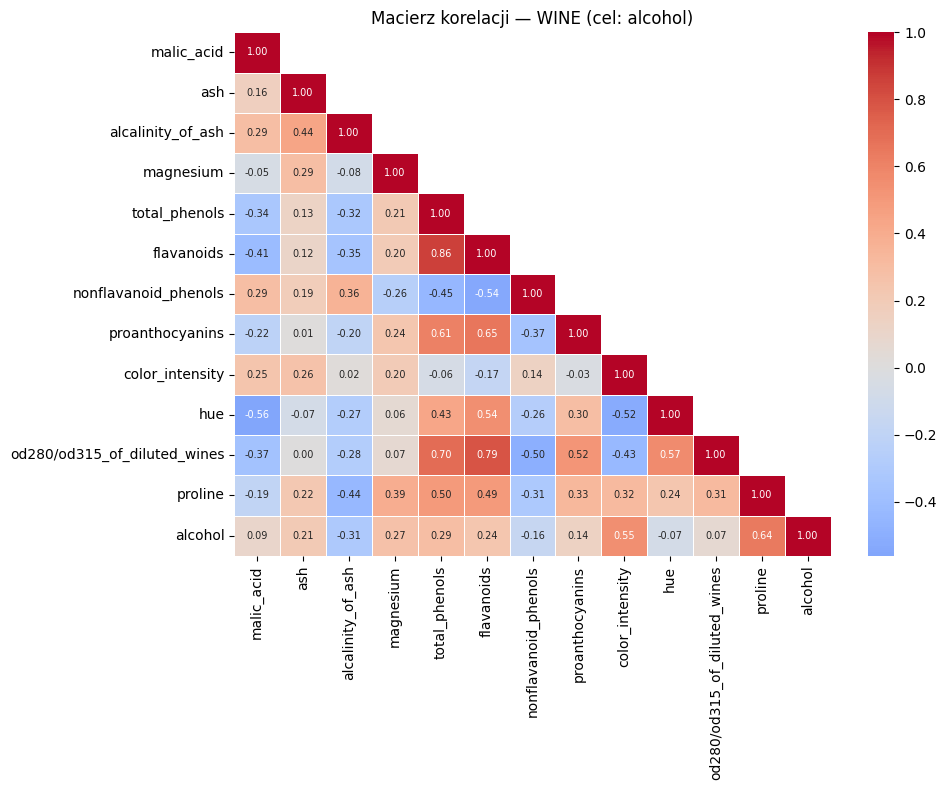

In [191]:
corr = df_wine[feature_cols + [target_col]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Macierz korelacji — WINE (cel: alcohol)', fontsize=12)
plt.tight_layout()
plt.show()

### Podział na train/test

In [192]:
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.2
)

print(f"Train: {X_wine_train.shape}, Test: {X_wine_test.shape}")

Train: (142, 12), Test: (36, 12)


### Regresja liniowa (LinearRegression)

In [193]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipe_lr.fit(X_wine_train, y_wine_train)

y_train_pred = pipe_lr.predict(X_wine_train)
y_test_pred  = pipe_lr.predict(X_wine_test)

print(f"Train — R²: {r2_score(y_wine_train, y_train_pred):.4f}, MSE: {mean_squared_error(y_wine_train, y_train_pred):.4f}")
print(f"Test  — R²: {r2_score(y_wine_test,  y_test_pred):.4f}, MSE: {mean_squared_error(y_wine_test,  y_test_pred):.4f}")

Train — R²: 0.6029, MSE: 0.2637
Test  — R²: 0.4512, MSE: 0.3399


Współczynniki regresji liniowej:
color_intensity                +0.4163
proline                        +0.2664
malic_acid                     +0.1761
flavanoids                     +0.1741
proanthocyanins                -0.1018
alcalinity_of_ash              -0.0842
hue                            +0.0646
od280/od315_of_diluted_wines   +0.0478
ash                            +0.0435
nonflavanoid_phenols           +0.0270
total_phenols                  +0.0116
magnesium                      +0.0115


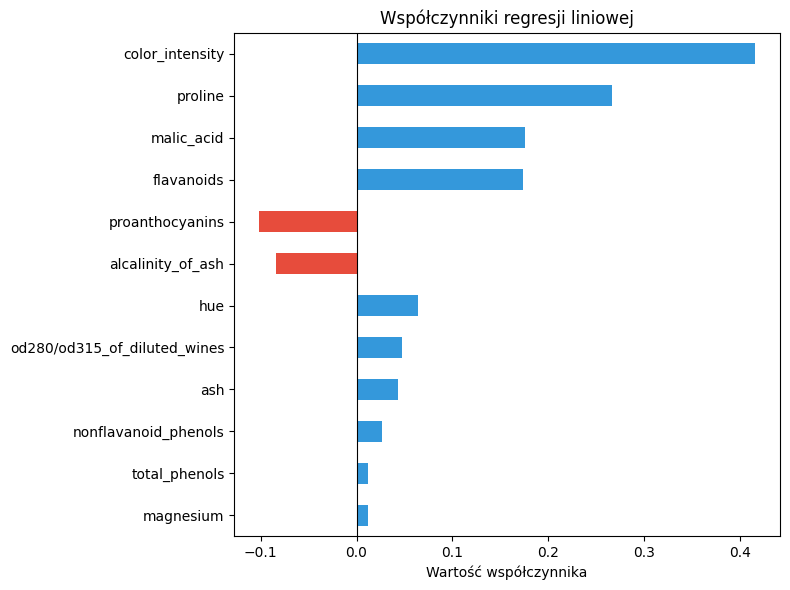

In [194]:
coef_df = pd.Series(pipe_lr.named_steps['model'].coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)

print("Współczynniki regresji liniowej:")
print(coef_df.to_string(float_format=lambda x: f"{x:+.4f}"))

coef_df_plot = coef_df.sort_values(key=np.abs, ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v < 0 else '#3498db' for v in coef_df_plot]
coef_df_plot.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Współczynniki regresji liniowej')
ax.set_xlabel('Wartość współczynnika')
plt.tight_layout()
plt.show()

| Cecha | |
|-------|-----------|
| color_intensity | intensywność koloru |
| proline | prolina (aminokwas) |
| flavanoids | flawonoidy (polifenole) |
| malic_acid | kwas jabłkowy |
| hue | odcień koloru |
| proanthocyanins | proantocyjaniny (polifenole) |
| od280/od315_of_diluted_wines | miara białek/fenoli (absorbancja światła) |
| alcalinity_of_ash | zasadowość popiołu |
| total_phenols | całkowita zawartość fenoli |
| ash | popiół (minerały nieorganiczne) |
| nonflavanoid_phenols | fenole nieflawaonoidowe |
| magnesium | magnez |

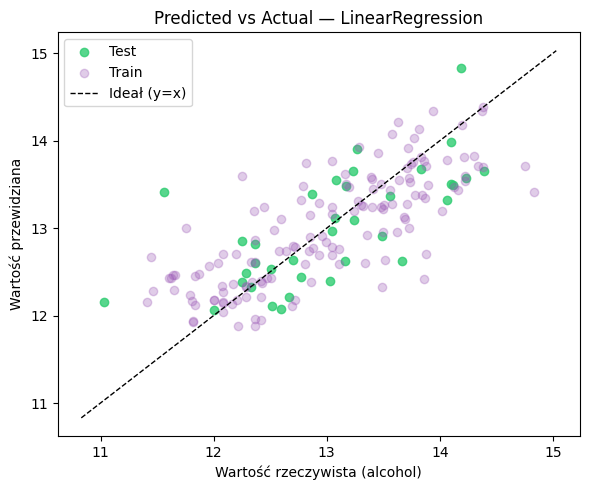

In [195]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_wine_test, y_test_pred, alpha=0.8, color='#2ecc71', label='Test')
ax.scatter(y_wine_train, y_train_pred, alpha=0.3, color='#9b59b6', label='Train')

lims = [min(y_wine.min(), y_test_pred.min()) - 0.2,
        max(y_wine.max(), y_test_pred.max()) + 0.2]
ax.plot(lims, lims, 'k--', linewidth=1, label='Ideał (y=x)')

ax.set_xlabel('Wartość rzeczywista (alcohol)')
ax.set_ylabel('Wartość przewidziana')
ax.set_title('Predicted vs Actual — LinearRegression')
ax.legend()
plt.tight_layout()
plt.show()

### Regularyzacja Ridge i Lasso — ścieżki współczynników

In [196]:
alphas = np.logspace(-3, 5, 100)
ridge_coefs = []
lasso_coefs = []

for alpha in tqdm(alphas, desc='Regularization path'):
    pipe_ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=alpha))])
    pipe_lasso = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=alpha, max_iter=10000))])
    
    pipe_ridge.fit(X_wine_train, y_wine_train)
    pipe_lasso.fit(X_wine_train, y_wine_train)
    
    ridge_coefs.append(pipe_ridge.named_steps['model'].coef_)
    lasso_coefs.append(pipe_lasso.named_steps['model'].coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

Regularization path:   0%|          | 0/100 [00:00<?, ?it/s]

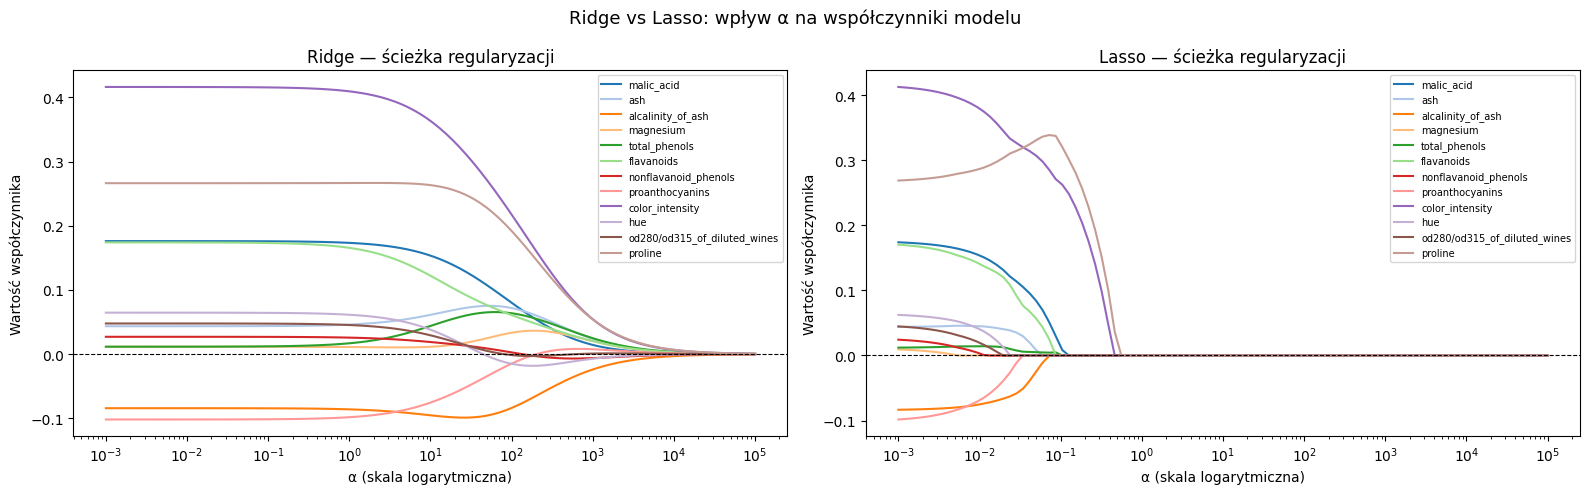

In [197]:
colors = plt.cm.tab20.colors[:len(feature_cols)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, name in enumerate(feature_cols):
    axes[0].plot(alphas, ridge_coefs[:, i], label=name, color=colors[i])
axes[0].set_xscale('log')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Ridge — ścieżka regularyzacji')
axes[0].set_xlabel('α (skala logarytmiczna)')
axes[0].set_ylabel('Wartość współczynnika')
axes[0].legend(fontsize=7, loc='upper right')

for i, name in enumerate(feature_cols):
    axes[1].plot(alphas, lasso_coefs[:, i], label=name, color=colors[i])
axes[1].set_xscale('log')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Lasso — ścieżka regularyzacji')
axes[1].set_xlabel('α (skala logarytmiczna)')
axes[1].set_ylabel('Wartość współczynnika')
axes[1].legend(fontsize=7, loc='upper right')

plt.suptitle('Ridge vs Lasso: wpływ α na współczynniki modelu', fontsize=13)
plt.tight_layout()
plt.show()

### Walidacja krzyżowa dla optymalnego α

Optimal α Ridge (CV):  19.1791
Optimal α Lasso (CV):  0.0163


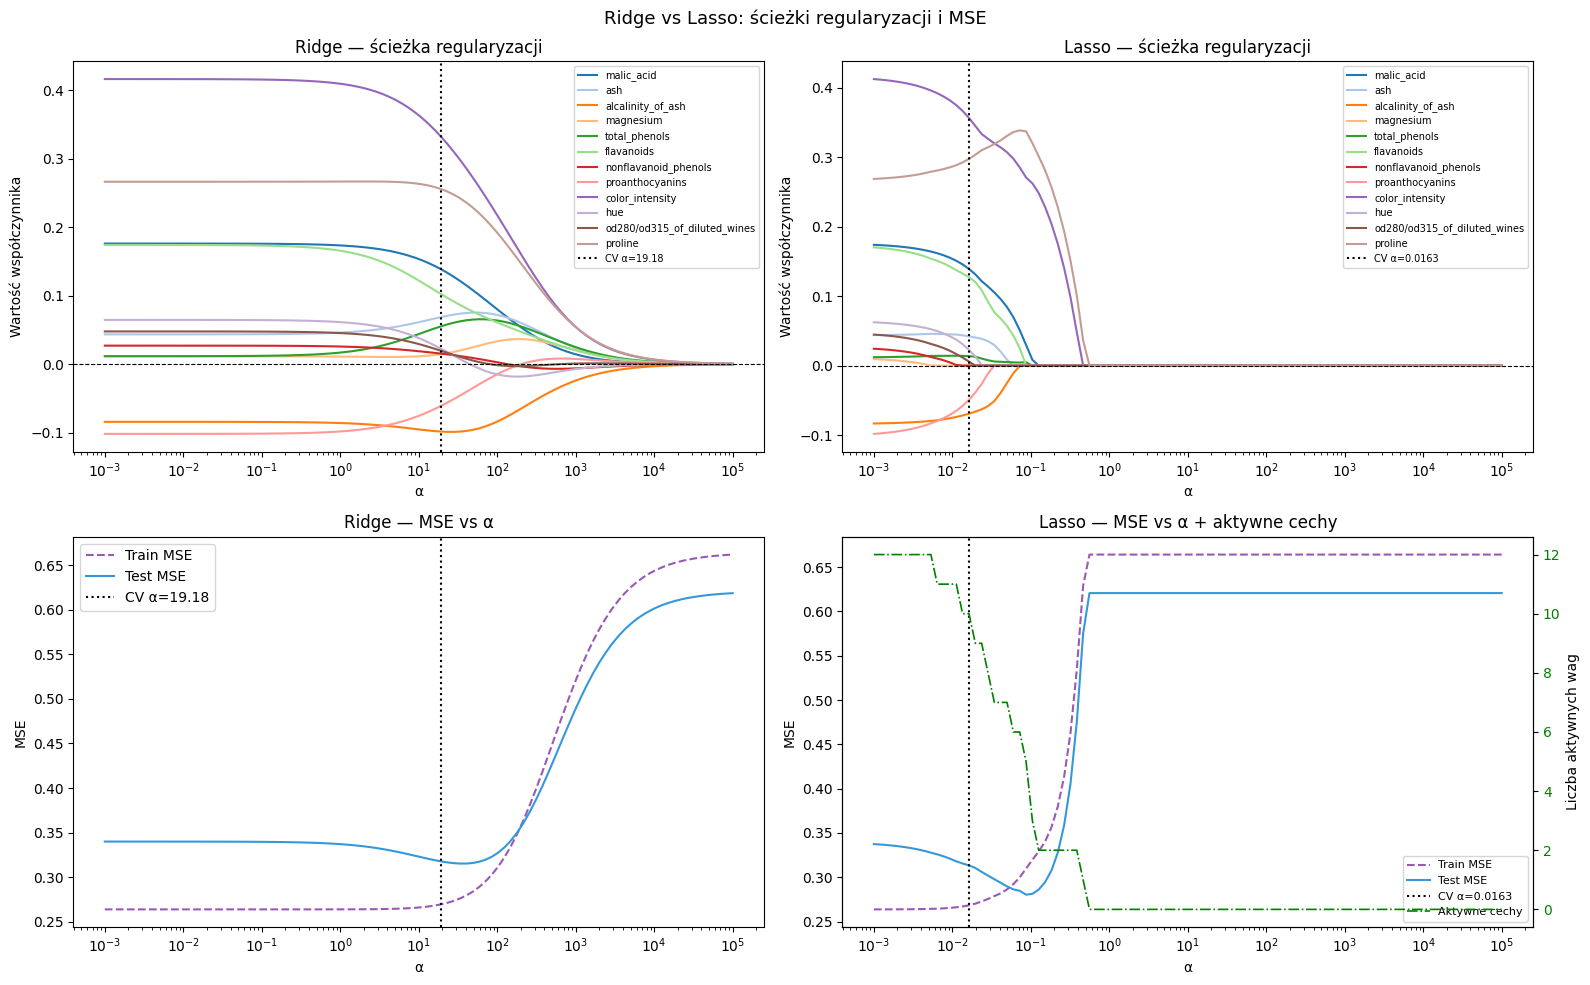

In [198]:
ridge_cv = Pipeline([('scaler', StandardScaler()), ('model', RidgeCV(alphas=alphas, scoring='r2', cv=5))])
ridge_cv.fit(X_wine_train, y_wine_train)
alpha_ridge_cv = ridge_cv.named_steps['model'].alpha_

lasso_cv = Pipeline([('scaler', StandardScaler()), ('model', LassoCV(alphas=alphas, cv=5, max_iter=10000))])
lasso_cv.fit(X_wine_train, y_wine_train)
alpha_lasso_cv = lasso_cv.named_steps['model'].alpha_

print(f"Optimal α Ridge (CV):  {alpha_ridge_cv:.4f}")
print(f"Optimal α Lasso (CV):  {alpha_lasso_cv:.4f}")

# MSE vs alpha (train + test)
ridge_mse_train, ridge_mse_test = [], []
lasso_mse_train, lasso_mse_test = [], []

for alpha in alphas:
    p_r = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=alpha))])
    p_l = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=alpha, max_iter=10000))])
    p_r.fit(X_wine_train, y_wine_train)
    p_l.fit(X_wine_train, y_wine_train)
    ridge_mse_train.append(mean_squared_error(y_wine_train, p_r.predict(X_wine_train)))
    ridge_mse_test.append(mean_squared_error(y_wine_test,   p_r.predict(X_wine_test)))
    lasso_mse_train.append(mean_squared_error(y_wine_train, p_l.predict(X_wine_train)))
    lasso_mse_test.append(mean_squared_error(y_wine_test,   p_l.predict(X_wine_test)))

colors = plt.cm.tab20.colors[:len(feature_cols)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Ridge — ścieżka współczynników
for i, name in enumerate(feature_cols):
    axes[0, 0].plot(alphas, ridge_coefs[:, i], label=name, color=colors[i])
axes[0, 0].axvline(alpha_ridge_cv, color='black', linewidth=1.5, linestyle=':', label=f'CV α={alpha_ridge_cv:.2f}')
axes[0, 0].set_xscale('log')
axes[0, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 0].set_title('Ridge — ścieżka regularyzacji')
axes[0, 0].set_xlabel('α')
axes[0, 0].set_ylabel('Wartość współczynnika')
axes[0, 0].legend(fontsize=7, loc='upper right')

# Lasso — ścieżka współczynników
for i, name in enumerate(feature_cols):
    axes[0, 1].plot(alphas, lasso_coefs[:, i], label=name, color=colors[i])
axes[0, 1].axvline(alpha_lasso_cv, color='black', linewidth=1.5, linestyle=':', label=f'CV α={alpha_lasso_cv:.4f}')
axes[0, 1].set_xscale('log')
axes[0, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 1].set_title('Lasso — ścieżka regularyzacji')
axes[0, 1].set_xlabel('α')
axes[0, 1].set_ylabel('Wartość współczynnika')
axes[0, 1].legend(fontsize=7, loc='upper right')

# Ridge — MSE vs alpha
axes[1, 0].plot(alphas, ridge_mse_train, color='#9b59b6', linestyle='--', label='Train MSE')
axes[1, 0].plot(alphas, ridge_mse_test,  color='#3498db', label='Test MSE')
axes[1, 0].axvline(alpha_ridge_cv, color='black', linewidth=1.5, linestyle=':', label=f'CV α={alpha_ridge_cv:.2f}')
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Ridge — MSE vs α')
axes[1, 0].set_xlabel('α')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].legend()

# Lasso — MSE vs alpha
# Lasso — MSE vs alpha + liczba aktywnych cech
ax_lasso_mse = axes[1, 1]
ax_lasso_nz  = ax_lasso_mse.twinx()

ax_lasso_mse.plot(alphas, lasso_mse_train, color='#9b59b6', linestyle='--', label='Train MSE')
ax_lasso_mse.plot(alphas, lasso_mse_test,  color='#3498db', label='Test MSE')
ax_lasso_mse.axvline(alpha_lasso_cv, color='black', linewidth=1.5, linestyle=':', label=f'CV α={alpha_lasso_cv:.4f}')
ax_lasso_mse.set_xscale('log')
ax_lasso_mse.set_title('Lasso — MSE vs α + aktywne cechy')
ax_lasso_mse.set_xlabel('α')
ax_lasso_mse.set_ylabel('MSE')

# liczba niezerowych współczynników dla każdego alpha
n_nonzero = []
for alpha in alphas:
    p = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=alpha, max_iter=10000))])
    p.fit(X_wine_train, y_wine_train)
    n_nonzero.append(np.sum(p.named_steps['model'].coef_ != 0))

ax_lasso_nz.plot(alphas, n_nonzero, color='green', linewidth=1.2, linestyle='-.', label='Aktywne cechy')
ax_lasso_nz.set_ylabel('Liczba aktywnych wag')
ax_lasso_nz.tick_params(axis='y', labelcolor='green')
ax_lasso_nz.set_yticks(range(0, len(feature_cols)+1, 2))

# połączone legendy
lines1, labels1 = ax_lasso_mse.get_legend_handles_labels()
lines2, labels2 = ax_lasso_nz.get_legend_handles_labels()
ax_lasso_mse.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
plt.suptitle('Ridge vs Lasso: ścieżki regularyzacji i MSE', fontsize=13)
plt.tight_layout()
plt.show()

### Podsumowanie — Zadanie 1

,R²_train,R²_test,MSE_train,MSE_test,Gap (train-test)
Model,,,,,
LinearRegression,0.6029,0.4512,0.2637,0.3399,0.1518
Ridge(α=1),0.6029,0.4558,0.2638,0.3370,0.1471
"Ridge(α=19.179, CV)",0.5944,0.4870,0.2694,0.3177,0.1074
Lasso(α=0.01),0.6001,0.4834,0.2656,0.3199,0.1166
"Lasso(α=0.0163, CV)",0.5960,0.4940,0.2684,0.3133,0.1020


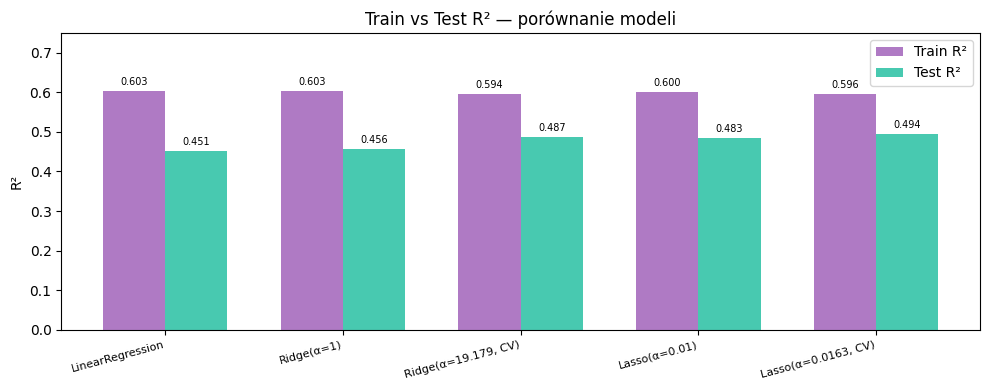

In [199]:
models_reg = [
    ('LinearRegression',                    Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])),
    ('Ridge(α=1)',                          Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1))])),
    (f'Ridge(α={alpha_ridge_cv:.3f}, CV)', Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=alpha_ridge_cv))])),
    ('Lasso(α=0.01)',                       Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.01, max_iter=10000))])),
    (f'Lasso(α={alpha_lasso_cv:.4f}, CV)', Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=alpha_lasso_cv, max_iter=10000))])),
]

rows = []
for name, model in models_reg:
    model.fit(X_wine_train, y_wine_train)
    ytr = model.predict(X_wine_train)
    yte = model.predict(X_wine_test)
    rows.append({
        'Model':     name,
        'R²_train':  r2_score(y_wine_train, ytr),
        'R²_test':   r2_score(y_wine_test, yte),
        'MSE_train': mean_squared_error(y_wine_train, ytr),
        'MSE_test':  mean_squared_error(y_wine_test, yte),
    })

results_df = pd.DataFrame(rows).set_index('Model')
results_df['Gap (train-test)'] = (results_df['R²_train'] - results_df['R²_test']).round(4)

display(results_df.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(results_df))
width = 0.35

bars_train = ax.bar(x - width/2, results_df['R²_train'], width, label='Train R²', color='#9b59b6', alpha=0.8)
bars_test  = ax.bar(x + width/2, results_df['R²_test'],  width, label='Test R²',  color='#1abc9c', alpha=0.8)

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('R²')
ax.set_title('Train vs Test R² — porównanie modeli')
ax.legend()
ax.set_ylim(0, 0.75)
plt.tight_layout()
plt.show()

---
# Zadanie 2: Klasyfikacja probabilistyczna — zbiór Bankrutów

### Wczytanie danych

In [200]:
dataset = fetch_ucirepo(id=365)
X_raw = dataset.data.features
y_raw = dataset.data.targets

df = X_raw.copy()
df['class'] = y_raw['class']

print(f"Pełny zbiór: {df.shape}")
print(f"Lata dostępne: {sorted(df['year'].unique())}")

Pełny zbiór: (43405, 66)
Lata dostępne: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


### Preprocessing

In [201]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - 1.5 * IQR
        self.upper_ = Q3 + 1.5 * IQR
        return self

    def transform(self, X, y=None):
        return np.clip(X, self.lower_, self.upper_)

In [202]:
# filtrujemy rok 4, usuwamy A37 (45% braków), wiersze z >7 brakami
df4 = df[df['year'] == 4].drop(columns=['year', 'A37'])
feat_cols = [c for c in df4.columns if c != 'class']
df4 = df4[df4[feat_cols].isnull().sum(axis=1) <= 7].reset_index(drop=True)

X = df4[feat_cols]
y = df4['class']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Po filtracji: {df4.shape}")
print(f"Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")
print(f"Bankruci train: {y_train.sum()} ({100*y_train.mean():.1f}%), test: {y_test.sum()} ({100*y_test.mean():.1f}%)")

Po filtracji: (9719, 64)
Train: (7775, 63), Test: (1944, 63)
Bankruci train: 406 (5.2%), test: 102 (5.2%)


In [203]:
preproc = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clipper', IQRClipper()),
    ('scaler',  StandardScaler()),
])

X_train_scaled = preproc.fit_transform(X_train_raw)
X_test_scaled  = preproc.transform(X_test_raw)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")

X_train_scaled shape: (7775, 63)
Mean: -0.0000, Std: 1.0000


### Regresja logistyczna — baseline

In [204]:
log_reg = LogisticRegression(C=1, class_weight='balanced', solver='lbfgs', max_iter=2000)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")

Accuracy:  0.7233
Precision: 0.1228
Recall:    0.6961
F1:        0.2088


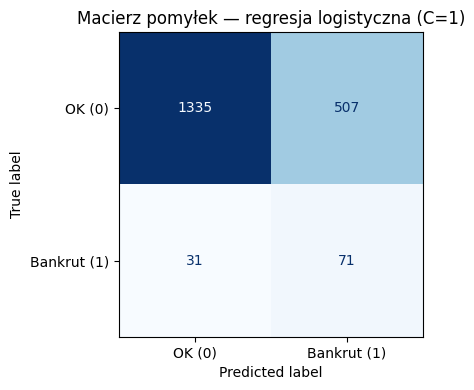

In [205]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['OK (0)', 'Bankrut (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek — regresja logistyczna (C=1)')
plt.tight_layout()
plt.show()

### Interpretacja wag modelu

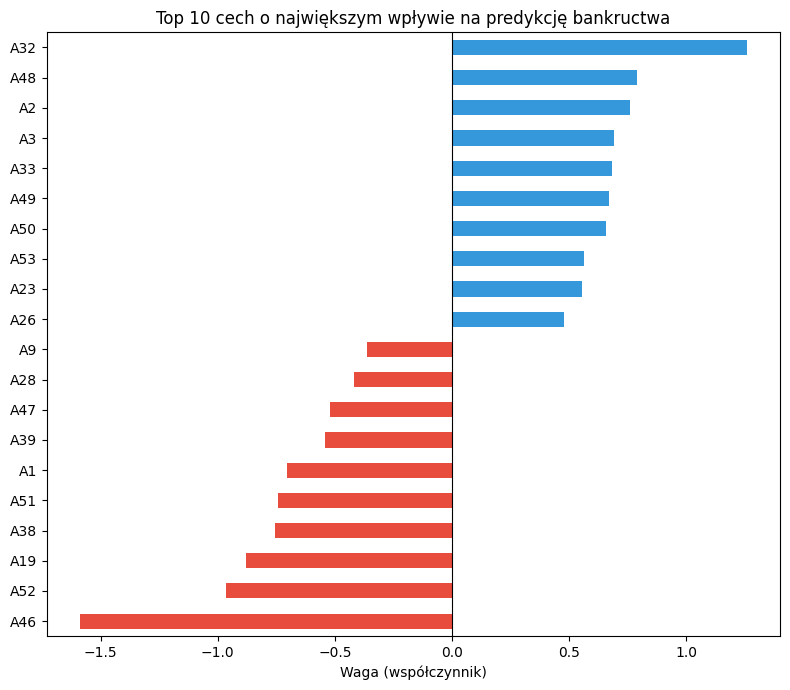

In [206]:
coefs = pd.Series(log_reg.coef_[0], index=feat_cols).sort_values()

top_neg = coefs.head(10)
top_pos = coefs.tail(10).iloc[::-1]
top_features = pd.concat([top_neg, top_pos]).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e74c3c' if v < 0 else '#3498db' for v in top_features]
top_features.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 cech o największym wpływie na predykcję bankructwa')
ax.set_xlabel('Waga (współczynnik)')
plt.tight_layout()
plt.show()

| Cecha | Znaczenie |
|---|---|
| A32 | (zobowiązania krótkoterminowe × 365) / koszt sprzedanych produktów |
| A48 | EBITDA / aktywa ogółem |
| A2 | zobowiązania ogółem / aktywa ogółem |
| A3 | kapitał obrotowy / aktywa ogółem |
| A33 | koszty operacyjne / zobowiązania krótkoterminowe |
| A49 | EBITDA / sprzedaż |
| A50 | aktywa obrotowe / zobowiązania ogółem |
| A53 | kapitał własny / aktywa trwałe |
| A23 | zysk netto / sprzedaż |
| A26 | (zysk netto + amortyzacja) / zobowiązania ogółem |
| A46 | (aktywa obrotowe - zapasy) / zobowiązania krótkoterminowe |
| A52 | (zobowiązania krótkoterminowe × 365) / koszt sprzedanych produktów |
| A19 | zysk brutto / sprzedaż |
| A38 | stały kapitał / aktywa ogółem |
| A51 | zobowiązania krótkoterminowe / aktywa ogółem |
| A1 | zysk netto / aktywa ogółem |
| A39 | zysk na sprzedaży / sprzedaż |
| A47 | (zapasy × 365) / koszt sprzedanych produktów |
| A28 | kapitał obrotowy / aktywa trwałe |
| A9 | sprzedaż / aktywa ogółem |

### Analiza progu klasyfikacji

In [207]:
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
thresh_results = []

for t in thresholds:
    y_t = (y_proba >= t).astype(int)
    thresh_results.append({
        'Próg': t,
        'Precision': precision_score(y_test, y_t, zero_division=0),
        'Recall':    recall_score(y_test, y_t, zero_division=0),
        'F1':        f1_score(y_test, y_t, zero_division=0),
    })

df_thresh = pd.DataFrame(thresh_results).set_index('Próg')
print(df_thresh.round(4))

        Precision  Recall     F1
Próg                            
0.1000     0.0612  0.9510 0.1149
0.2000     0.0707  0.9118 0.1313
0.3000     0.0839  0.8627 0.1529
0.4000     0.0992  0.7745 0.1759
0.5000     0.1228  0.6961 0.2088
0.6000     0.1330  0.5294 0.2126
0.7000     0.1687  0.4118 0.2393
0.8000     0.2190  0.2941 0.2510
0.9000     0.3617  0.1667 0.2282


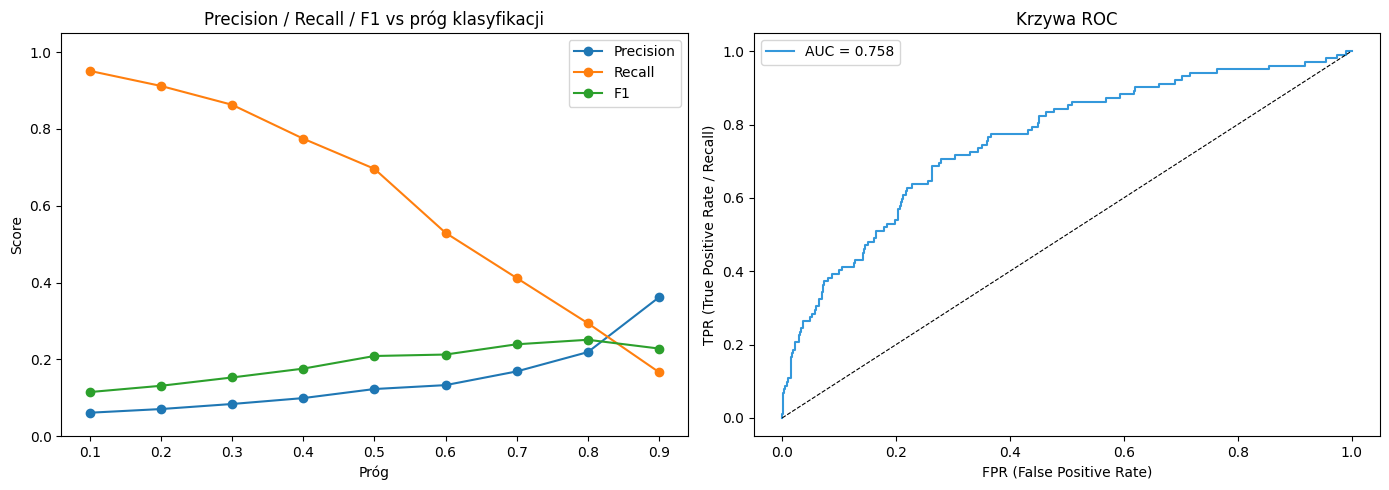

In [208]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_thresh.plot(ax=axes[0], marker='o')
axes[0].set_title('Precision / Recall / F1 vs próg klasyfikacji')
axes[0].set_xlabel('Próg')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#3498db', label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title('Krzywa ROC')
axes[1].set_xlabel('FPR (False Positive Rate)')
axes[1].set_ylabel('TPR (True Positive Rate / Recall)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Wpływ parametru C na jakość modelu

CV sweep Ridge (L2):   0%|          | 0/20 [00:00<?, ?it/s]

CV sweep Lasso (L1):   0%|          | 0/20 [00:00<?, ?it/s]

Aktywne wagi:   0%|          | 0/20 [00:00<?, ?it/s]

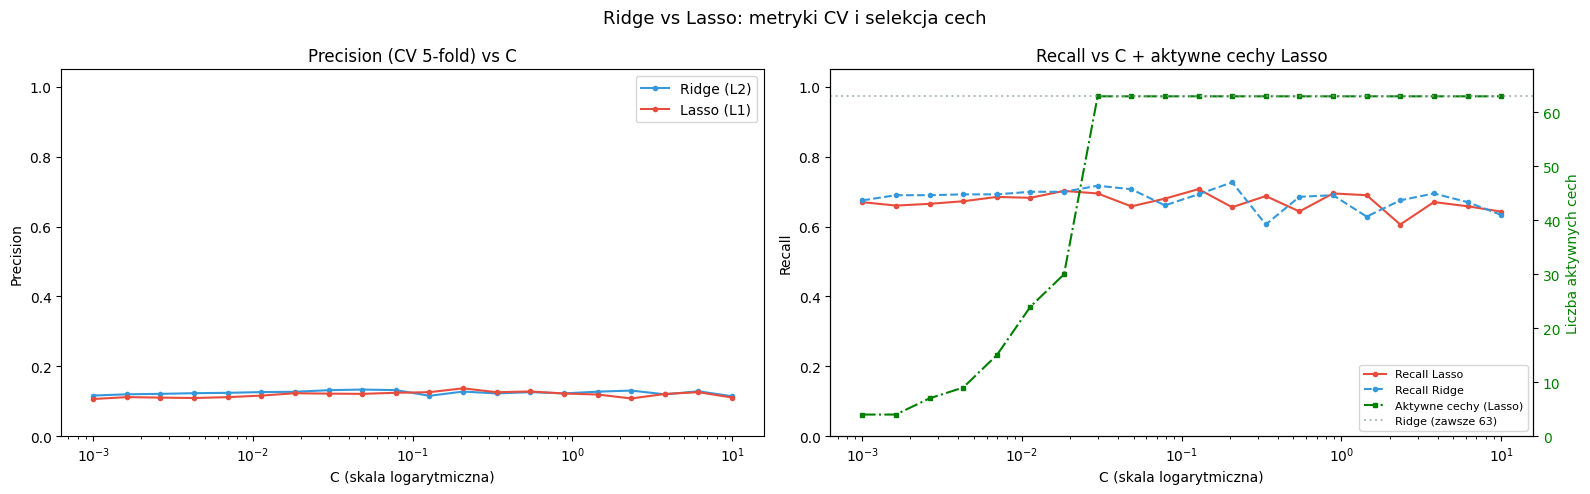

Ridge (L2):
  najlepszy Recall    C=0.20691 → 0.7266 ± 0.0505
  najlepsza Precision C=0.04833 → 0.1333 ± 0.0095
Lasso (L1):
  najlepszy Recall    C=0.12743 → 0.7070 ± 0.0569
  najlepsza Precision C=0.20691 → 0.1368 ± 0.0054


In [222]:
C_values = np.logspace(-3, 1, 20).tolist()  
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for l1r, label in [(0.0, 'Ridge (L2)'), (1.0, 'Lasso (L1)')]:
    rec_means, rec_stds = [], []
    pre_means, pre_stds = [], []
    for C in tqdm(C_values, desc=f'CV sweep {label}'):
        m = LogisticRegression(C=C, l1_ratio=l1r, solver='saga',
                               class_weight='balanced', max_iter=2000)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=(FutureWarning, ConvergenceWarning, UndefinedMetricWarning))
            scores = cross_validate(m, X_train_scaled, y_train, cv=cv,
                                    scoring=['recall', 'precision'],
                                    error_score=0.0)
        rec_means.append(scores['test_recall'].mean())
        rec_stds.append(scores['test_recall'].std())
        pre_means.append(scores['test_precision'].mean())
        pre_stds.append(scores['test_precision'].std())
    cv_results[label] = {
        'recall_means': np.array(rec_means), 'recall_stds': np.array(rec_stds),
        'precision_means': np.array(pre_means), 'precision_stds': np.array(pre_stds),
    }

# aktywne wagi dla każdego C (tylko Lasso)
active_counts = []
for C in tqdm(C_values, desc='Aktywne wagi'):
    m = LogisticRegression(C=C, l1_ratio=1.0, solver='saga',
                           class_weight='balanced', max_iter=2000)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        m.fit(X_train_scaled, y_train)
    active_counts.append(int(np.sum(np.abs(m.coef_[0]) >= 1e-4)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# lewy: precision
for label, res in cv_results.items():
    c = '#3498db' if 'Ridge' in label else '#e74c3c'
    axes[0].plot(C_values, res['precision_means'], marker='o', markersize=3, color=c, label=label)
axes[0].set_xscale('log')
axes[0].set_xlabel('C (skala logarytmiczna)')
axes[0].set_ylabel('Precision')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Precision (CV 5-fold) vs C')
axes[0].legend()

# prawy: recall + aktywne cechy
ax_rec = axes[1]
ax_nz  = ax_rec.twinx()

ax_rec.plot(C_values, cv_results['Lasso (L1)']['recall_means'],
            color='#e74c3c', marker='o', markersize=3, label='Recall Lasso')
ax_rec.plot(C_values, cv_results['Ridge (L2)']['recall_means'],
            color='#3498db', marker='o', markersize=3, linestyle='--', label='Recall Ridge')
ax_rec.set_ylabel('Recall')
ax_rec.set_ylim(0, 1.05)

ax_nz.plot(C_values, active_counts, color='green', marker='s',
           markersize=3, linestyle='-.', label='Aktywne cechy (Lasso)')
ax_nz.axhline(len(feat_cols), color='#95a5a6', linestyle=':', alpha=0.7,
              label=f'Ridge (zawsze {len(feat_cols)})')
ax_nz.set_ylabel('Liczba aktywnych cech', color='green')
ax_nz.tick_params(axis='y', labelcolor='green')
ax_nz.set_ylim(0, len(feat_cols) + 5)

ax_rec.set_xscale('log')
ax_rec.set_xlabel('C (skala logarytmiczna)')
ax_rec.set_title('Recall vs C + aktywne cechy Lasso')

lines1, labels1 = ax_rec.get_legend_handles_labels()
lines2, labels2 = ax_nz.get_legend_handles_labels()
ax_rec.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)

plt.suptitle('Ridge vs Lasso: metryki CV i selekcja cech', fontsize=13)
plt.tight_layout()
plt.show()

for label, res in cv_results.items():
    best_rec_idx = int(np.argmax(res['recall_means']))
    best_pre_idx = int(np.argmax(res['precision_means']))
    print(f"{label}:")
    print(f"  najlepszy Recall    C={C_values[best_rec_idx]:.5f} → {res['recall_means'][best_rec_idx]:.4f} ± {res['recall_stds'][best_rec_idx]:.4f}")
    print(f"  najlepsza Precision C={C_values[best_pre_idx]:.5f} → {res['precision_means'][best_pre_idx]:.4f} ± {res['precision_stds'][best_pre_idx]:.4f}")

### Ridge vs Lasso — porównanie regularyzacji

In [223]:
# wyciągnij optymalne C z poprzedniego CV sweepа
best_C_ridge = C_values[int(np.argmax(cv_results['Ridge (L2)']['recall_means']))]
best_C_lasso = C_values[int(np.argmax(cv_results['Lasso (L1)']['recall_means']))]

penalties = [
    ('Ridge (L2, C=0.01)', LogisticRegression(C=0.01,         l1_ratio=0, class_weight='balanced', solver='saga', max_iter=5000)),
    ('Ridge (L2, C=1)',    LogisticRegression(C=1,             l1_ratio=0, class_weight='balanced', solver='saga', max_iter=5000)),
    ('Ridge (L2, C=10)',   LogisticRegression(C=10,            l1_ratio=0, class_weight='balanced', solver='saga', max_iter=5000)),
    (f'Ridge (L2, C={best_C_ridge:.3f} CV)', LogisticRegression(C=best_C_ridge, l1_ratio=0, class_weight='balanced', solver='saga', max_iter=5000)),
    ('Lasso (L1, C=0.01)', LogisticRegression(C=0.01,         l1_ratio=1, class_weight='balanced', solver='saga', max_iter=5000)),
    ('Lasso (L1, C=1)',    LogisticRegression(C=1,             l1_ratio=1, class_weight='balanced', solver='saga', max_iter=5000)),
    ('Lasso (L1, C=10)',   LogisticRegression(C=10,            l1_ratio=1, class_weight='balanced', solver='saga', max_iter=5000)),
    (f'Lasso (L1, C={best_C_lasso:.3f} CV)', LogisticRegression(C=best_C_lasso, l1_ratio=1, class_weight='balanced', solver='saga', max_iter=5000)),
]

pen_results = []
for name, model in tqdm(penalties, desc='Ridge vs Lasso'):
    model.fit(X_train_scaled, y_train)
    yp = model.predict(X_test_scaled)
    n_zero = np.sum(np.abs(model.coef_[0]) < 1e-4)
    pen_results.append({
        'Model':        name,
        'Precision':    precision_score(y_test, yp, zero_division=0),
        'Recall':       recall_score(y_test, yp, zero_division=0),
        'F1':           f1_score(y_test, yp, zero_division=0),
        'Wagi ≈ 0':     int(n_zero),
        'Wagi aktywne': int(len(feat_cols) - n_zero),
    })

df_pen = pd.DataFrame(pen_results).set_index('Model')
df_pen

Ridge vs Lasso:   0%|          | 0/8 [00:00<?, ?it/s]

,Precision,Recall,F1,Wagi ≈ 0,Wagi aktywne
Model,,,,,
"Ridge (L2, C=0.01)",0.1157,0.6863,0.1980,0,63
"Ridge (L2, C=1)",0.1260,0.4804,0.1996,0,63
"Ridge (L2, C=10)",0.1238,0.6176,0.2062,0,63
"Ridge (L2, C=0.207 CV)",0.1184,0.5294,0.1935,0,63
"Lasso (L1, C=0.01)",0.1096,0.6961,0.1893,42,21
"Lasso (L1, C=1)",0.1199,0.6569,0.2027,0,63
"Lasso (L1, C=10)",0.0979,0.6961,0.1717,0,63
"Lasso (L1, C=0.127 CV)",0.1090,0.6667,0.1873,0,63


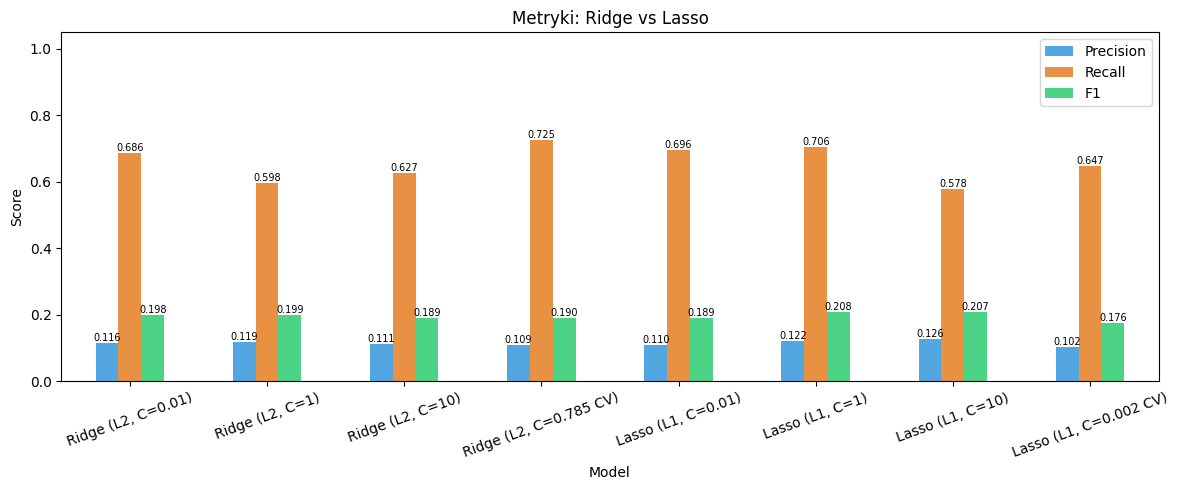

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

df_pen[['Precision', 'Recall', 'F1']].plot.bar(ax=ax, color=['#3498db', '#e67e22', '#2ecc71'], alpha=0.85)
ax.set_title('Metryki: Ridge vs Lasso')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
ax.legend()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()